
## This project builds a machine learning model to detect fraudulent credit card transactions using transaction-level data.
#### Fraud detection is critical for fintech companies processing millions of daily transactions. The goal of this project is to build a model that detects fraudulent transactions while minimizing false positives.

In [1]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split


In [2]:
# Get the data
df = pd.read_csv('data/creditcard.csv')

---
### 1. Data Exploration
We want to get a feel for the data, counts of fraudulant transactions to get a sense of what we will be looking into as well as to check there is nothing wrong with the input dataset 

In [3]:
df.size

8829017

In [4]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [5]:
df_fraud = df[df.Class == 1]

print("Number of fraudulent transactions: ",df[df.Class==1]["Class"].size)
print("Number of transactions: ",df[df.Class==0]["Class"].size)
print("Fraudulent transaction rate: ", df[df.Class==1]["Class"].size/df["Class"].size)

Number of fraudulent transactions:  492
Number of transactions:  284315
Fraudulent transaction rate:  0.001727485630620034


We can see here that there are roughly 0.17% of transactions being flagged as fraudulant 

In [6]:
df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64

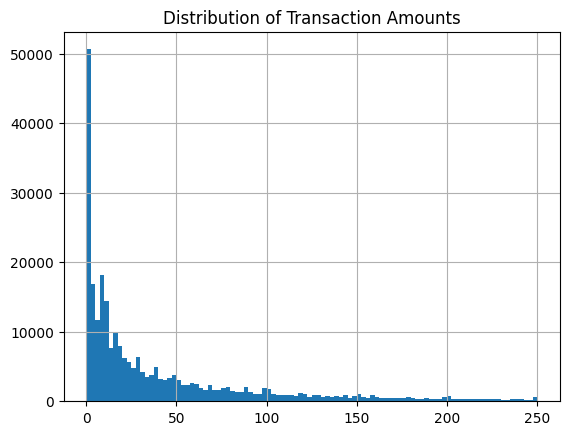

In [7]:
# Get a cleaner look at the distribution of the Amount feature by removing the outliers
#df[(df['Amount'] <= df['Amount'].quantile(0.99)) & (df['Amount'] >= df['Amount'].quantile(0.01))]['Amount'].hist(bins=100)
df[(df['Amount'] <= 250) & (df['Amount'] >= 0)]['Amount'].hist(bins=100)
plt.title('Distribution of Transaction Amounts')
df['Amount'].describe()

-----------------------------------
### 2. Build initial model, Logistic Regression
We want to now look at a *test and train* split to start training a model to test for fraudulant transactions

In [8]:
# Create the training and testing datasets
x = df.drop('Class', axis=1)
y = df['Class']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

In [9]:
print("Train fraud ratio:", y_train.mean())
print("Test fraud ratio:", y_test.mean())

Train fraud ratio: 0.001729245759178389
Test fraud ratio: 0.0017204452090867595


In [10]:
## add a pipline to scale the Amount feature and then train a logistic regression model
from imblearn.pipeline import Pipeline                   
from imblearn.over_sampling import SMOTE                 
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
model = Pipeline([('scaler', StandardScaler()),
                   ('smote', SMOTE(random_state=42)),
                   ('logistic', LogisticRegression(random_state=42, max_iter=1000))
                   ])

A pipeline was introduced to ensure preprocessing steps such as scaling are consistently applied during both training and evaluation, and to prevent data leakage. While performance may not change significantly due to the nature of the dataset, the pipeline improves robustness and maintainability.

Due to class imbalance, SMOTE was applied to the training data to generate synthetic minority class samples. This improved the model’s ability to detect fraudulent transactions, particularly increasing recall, while maintaining a reasonable precision-recall trade-off as this is used instead of accuracy. PR-AUC focuses on the model’s ability to detect fraudulent transactions while maintaining reasonable precision.

In [11]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=10000)
model.fit(x_train, y_train)
y_scores = model.predict_proba(x_test)[:,1]
from sklearn.metrics import roc_auc_score
from sklearn.metrics import average_precision_score
roc_auc = roc_auc_score(y_test, y_scores)
pr_auc = average_precision_score(y_test, y_scores)
print("ROC-AUC: ", roc_auc)
print("PR-AUC: ", pr_auc)

ROC-AUC:  0.9567410391280879
PR-AUC:  0.740956007193493


We want to cross validate to check for robustness and that we havent just got 'lucky' with our model 

In [12]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, x, y, cv=5, scoring='average_precision')
print(scores.mean())

0.739409341452261


In [13]:
print(scores)

[0.6122128  0.84461405 0.67473373 0.82033913 0.745147  ]


While the model achieved a high ROC-AUC, PR-AUC was used as the primary evaluation metric due to the extreme class imbalance.

Text(0.5, 1.0, 'Distribution of Predicted Probabilities for Fraudulent Transactions')

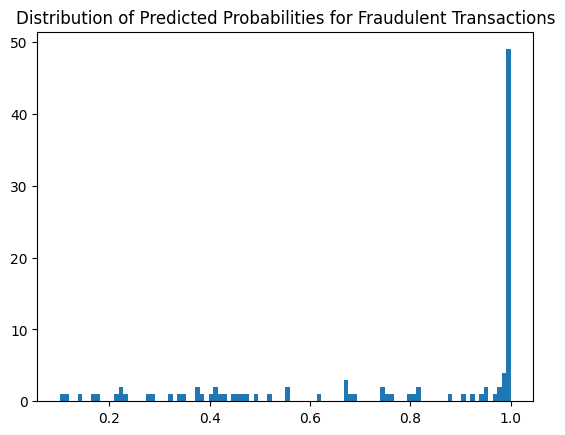

In [14]:
plt.hist(y_scores[y_scores > 0.1],bins=100)
plt.title('Distribution of Predicted Probabilities for Fraudulent Transactions')

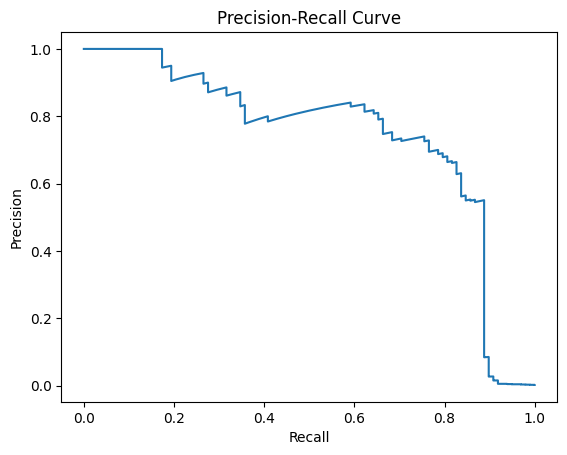

In [15]:
from sklearn.metrics import precision_recall_curve
precision, recall, thresholds = precision_recall_curve(y_test, y_scores)

plt.plot(recall, precision)     
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.show()

---
### 3. Exploring tree-based models 
#### 3.1 Random Forest
Logistic regression is a good baseline due to its simplicity and interpretability. However, for tabular data with nonlinear relationships, I would typically explore tree-based models such as Random Forest or Gradient Boosting, and compare performance using appropriate metrics like PR-AUC.

In [16]:
# Random forest model to see if it can do better than logistic regression
from sklearn.ensemble import RandomForestClassifier
rf_model = Pipeline([('scaler', StandardScaler()),
                   ('smote', SMOTE(random_state=42)),
                   ('model', RandomForestClassifier(random_state=42))
                   ])

#rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(x_train, y_train) 
rf_scores = rf_model.predict_proba(x_test)[:,1]
rf_roc_auc = roc_auc_score(y_test, rf_scores)
rf_pr_auc = average_precision_score(y_test, rf_scores)
print("Random Forest ROC-AUC: ", rf_roc_auc)
print("Random Forest PR-AUC: ", rf_pr_auc)

Random Forest ROC-AUC:  0.9684509513569075
Random Forest PR-AUC:  0.8723312785942332


We see a fair improvement in the PR-AUC score from 74% with Logistic Regression to 87% with Random Forrest, I want to finally test XGBoost as my final model to be certain we have the best model.

#### 3.2 XGBoost

In [17]:
# XGBoost model to see if it can do better than random forest
from xgboost import XGBClassifier
xgb_model = Pipeline([('scaler', StandardScaler()),
                   ('smote', SMOTE(random_state=42)),
                   ('model', XGBClassifier(random_state=42))
                   ])
#xgb_model = XGBClassifier(n_estimators=100, random_state=42)
xgb_model.fit(x_train, y_train)
xgb_scores = xgb_model.predict_proba(x_test)[:,1]
xgb_roc_auc = roc_auc_score(y_test, xgb_scores)
xgb_pr_auc = average_precision_score(y_test, xgb_scores)
print("XGBoost ROC-AUC: ", xgb_roc_auc)
print("XGBoost PR-AUC: ", xgb_pr_auc)

XGBoost ROC-AUC:  0.9799832109264639
XGBoost PR-AUC:  0.8682821332846721


In [18]:
# I want to get a table of the results for all three models
results = pd.DataFrame({'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'ROC-AUC': [roc_auc, rf_roc_auc, xgb_roc_auc],
    'PR-AUC': [pr_auc, rf_pr_auc, xgb_pr_auc]})

print(results)

                 Model   ROC-AUC    PR-AUC
0  Logistic Regression  0.956741  0.740956
1        Random Forest  0.968451  0.872331
2              XGBoost  0.979983  0.868282


We want to cross validate each model to check we have not got 'lucky' with out models 

In [ ]:
pipelines = {
    "Logistic Regression": model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model
}

for name, pipe in pipelines.items():
    scores = cross_val_score(pipe, x, y, cv=5, scoring='average_precision')
    print(name, scores.mean())

Logistic Regression 0.739409341452261
Random Forest 0.7405789404946678
XGBoost 0.7588239508576422


Model performance on imbalanced datasets can be highly sensitive to the train-test split, so cross-validation is essential to obtain a reliable estimate.

--- 
### 4. Findings
Initial model evaluation using a single train-test split suggested that Random Forest and XGBoost significantly outperformed Logistic Regression. However, cross-validation revealed that performance across all models was more similar (~0.75 PR-AUC), indicating that the initial results were likely influenced by variance in the data split. This highlights the importance of robust evaluation techniques, particularly in imbalanced datasets.

#### Next steps:
I would look to tune the hyperparameters of the Random Forest and XGBoost as both of these can be let down by poor input parameters such as overfitting if the depth of the trees are too high.

---
### 5. Followups


In [19]:
# Craete a table of parameters to cycle through for the random forest and xgboost models to see if we can improve the results

param_grid_rf = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [None, 10, 20],
    'model__min_samples_split': [2, 5],
}


param_grid_xgb = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [3, 6],
    'model__learning_rate': [0.01, 0.1],
}

In [20]:
from sklearn.model_selection import GridSearchCV

grid_rf = GridSearchCV(
    rf_model,
    param_grid_rf,
    scoring='average_precision',  # PR-AUC
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_rf.fit(x_train, y_train)

print(grid_rf.best_params_)
print(grid_rf.best_score_)

best_rf = grid_rf.best_estimator_

Fitting 5 folds for each of 12 candidates, totalling 60 fits
{'model__max_depth': None, 'model__min_samples_split': 5, 'model__n_estimators': 200}
0.8467473871182319


In [25]:
grid_xgb = GridSearchCV(
    xgb_model,
    param_grid_xgb,
    scoring='average_precision',  # PR-AUC
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_xgb.fit(x_train, y_train)

print(grid_xgb.best_params_)
print(grid_xgb.best_score_)

best_xgb = grid_xgb.best_estimator_

Fitting 5 folds for each of 8 candidates, totalling 40 fits
{'model__learning_rate': 0.1, 'model__max_depth': 6, 'model__n_estimators': 200}
0.8382647413651627


Hyperparameter tuning did not significantly improve performance over default settings, suggesting that the model is relatively robust to parameter changes on this dataset. Cross-validation results indicate that earlier higher scores were likely due to variance in the train-test split.

---
### 6. Summary

#### 6.1 Summary
This project developed a fraud detection system using a range of machine learning models, including Logistic Regression, Random Forest, and XGBoost.

Given the highly imbalanced nature of the dataset, particular emphasis was placed on:

    Appropriate evaluation metrics (PR-AUC rather than accuracy)

    Handling class imbalance using SMOTE

    Robust validation through cross-validation

Initial results from a single train-test split suggested that tree-based models significantly outperformed Logistic Regression. However, after implementing cross-validation, model performance converged to a similar level (~0.75 PR-AUC), indicating that earlier results were influenced by variance in the data split.

Hyperparameter tuning was applied using cross-validation, and we saw significant improvement from ~0.75 to ~0.84. This suggests that going forward we use the random forrest model with the hyperparameters mentioned above.



---

### 7 Business Implications

This project highlights several important considerations when deploying fraud detection models in a real-world financial setting.

##### 1. Model Choice vs Practicality
Although more complex models such as Random Forest and XGBoost were explored, cross-validation showed that performance differences between models were relatively small.

This suggests that:
- Simpler models such as Logistic Regression may be preferable in production
- Benefits include interpretability, faster deployment, and easier regulatory compliance

In highly regulated industries like finance, model transparency is often as important as raw performance.

---

##### 2. Importance of Robust Evaluation
Initial results from a single train-test split suggested significantly stronger model performance. However, cross-validation revealed that these results were likely optimistic due to variance in the data split.

This demonstrates that:
- Single split evaluation can be misleading, especially with imbalanced datasets
- Cross-validation provides a more reliable estimate of real-world performance

For fraud detection systems, overestimating model performance could lead to financial and reputational risk.

---

##### 3. Precision vs Recall Trade-off
Fraud detection is fundamentally a trade-off between identifying fraudulent transactions and minimising false positives.

- High recall → More fraud detected, but more legitimate transactions flagged  
- High precision → Fewer false alerts, but more fraud may go undetected  

Through threshold optimisation, the model can be adjusted depending on business priorities:
- Fraud prevention focus → optimise for recall  
- Customer experience focus → optimise for precision  

This highlights that model deployment should align with business strategy rather than purely technical metrics.

---

##### 4. Diminishing Returns from Model Complexity
Despite using advanced models and hyperparameter tuning, performance improvements were limited.

This suggests that:
- The dataset (particularly PCA-transformed features) may limit further gains
- Increasing model complexity does not guarantee better outcomes

In practice, this reinforces the importance of data quality and feature engineering over model selection alone.

---

##### 5. Need for a Robust and Reproducible Pipeline
The use of pipelines ensured that preprocessing steps such as SMOTE were correctly applied within cross-validation, preventing data leakage.

This is critical because:
- Data leakage can significantly inflate performance metrics
- Reproducibility is essential for production systems and audits

A well-structured pipeline reflects best practices required for deploying machine learning models in real-world environments.

---

##### 6. Decision Threshold as a Business Lever
Rather than relying on a fixed classification threshold (e.g. 0.5), threshold optimisation allows the business to control how the model behaves in practice.

This enables:
- Dynamic adjustment based on fraud trends
- Alignment with risk appetite and operational capacity

In production, this threshold can be continuously monitored and updated as conditions change.

---

#####  Final Takeaway

Overall, this project demonstrates that in fraud detection:
- Robust evaluation techniques are essential
- Handling class imbalance is critical
- Business context should guide model decisions

Ultimately, the value of a fraud detection system lies not just in predictive performance, but in how effectively it balances financial risk, customer experience, and operational efficiency.
